## Bayesian Modelling of Extreme Flows According for Physical-Geographic Features in Vistula Basin

Paweł Jerzyna, Piotr Grzyb

In [15]:
import os
import sys
import glob
import re
from pathlib import Path

from cmdstanpy import CmdStanModel

import arviz as az
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path(os.getcwd())
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

DATASET_DIR_CLEAN = PROJECT_ROOT / "cleaned_dataset"
DATASET_DIR_TXT = DATASET_DIR_CLEAN / "dataset_cleaned_AAAA"
DATASET_DIR_CSV = DATASET_DIR_CLEAN / "dataset_cleaned_AAA_csv"

sys.path.append(str(PROJECT_ROOT))




# No module named 'nbfomrmat' error - fix this later
#from utils.notebook import run_notebook
#from utils.display import display_df, display_image
"""
ten folder utils jest podjerzany (stworzony przez czat)
jak chcestawiac docker, to chociaz aby byl on dobzre zrobiony, a nie taki byle jaki
"""

'\nten folder utils jest podjerzany (stworzony przez czat)\njak chcestawiac docker, to chociaz aby byl on dobzre zrobiony, a nie taki byle jaki\n'

## Czyszczenie danych: Ekstrakcja lat 2023-2025 z surowego datasetu do folderu dataset_cleaned_AAAA

In [16]:
def clean_grdc_file(file_path, output_path):
    metadata = {
        "River": "Nieznana",
        "Station": "Nieznana",
        "Country": "Nieznany",
        "Latitude": "-999.000",
        "Longitude": "-999.000",
        "Catchment": "-999.00",
        "Altitude": "-999.00"
    }
    
    data_lines = []
    
    # Odczyt w kodowaniu 'latin-1' chroni przed błędem crashowania na jednostkach typu km²
    with open(file_path, 'r', encoding='latin-1') as f:
        lines = f.readlines()
        
    for i, line in enumerate(lines):
        stripped = line.strip()
        
        # Przetwarzanie linii nagłówkowych
        if stripped.startswith('#'):
            content = stripped[1:].strip()
            
            if "River:" in content:
                metadata["River"] = content.split("River:")[1].strip()
            elif "Station:" in content:
                metadata["Station"] = content.split("Station:")[1].strip()
            elif "Country:" in content:
                metadata["Country"] = content.split("Country:")[1].strip()
            elif "Latitude (DD):" in content:
                metadata["Latitude"] = content.split("Latitude (DD):")[1].strip()
            elif "Longitude (DD):" in content:
                metadata["Longitude"] = content.split("Longitude (DD):")[1].strip()
            elif "Catchment area" in content:
                val = content.split(":")[-1].strip()
                if not val and i + 1 < len(lines):
                    next_line = lines[i+1].strip()
                    if next_line.startswith('#'):
                        next_line = next_line[1:].strip()
                    if next_line and ';' not in next_line:
                        val = next_line
                metadata["Catchment"] = val if val else "-999.00"
            elif "Altitude (m ASL):" in content:
                metadata["Altitude"] = content.split("Altitude (m ASL):")[1].strip()
                
        # Przetwarzanie linii z pomiarami
        else:
            if ';' in stripped and not stripped.startswith('YYYY'):
                parts = stripped.split(';')
                if parts:
                    date_part = parts[0].strip()
                    try:
                        # Wyciągamy rok i filtrujemy pod kątem lat 2023, 2024, 2025
                        year = int(date_part.split('-')[0])
                        if year in [2023, 2024, 2025]:
                            data_lines.append(line.rstrip())
                    except (ValueError, IndexError):
                        pass

    # Jeśli stacja nie posiada danych z lat 2023-2025, nie generujemy pliku wyjściowego
    if not data_lines:
        return False
    
    # Budowanie struktury pliku tekstowego z zachowaniem idealnego wyrównania spacji
    output_lines = [
        f"River: {metadata['River']}",
        f"Station: {metadata['Station']}",
        f"Country: {metadata['Country']}",
        f"Latitude (DD):       {metadata['Latitude']}",
        f"Longitude (DD):      {metadata['Longitude']}",
        f"Catchment area (km²):      {metadata['Catchment']}",
        f"Altitude (m ASL):        {metadata['Altitude']}",
        "" # Pusta linia oddzielająca metadane od danych
    ]
    
    output_lines.extend(data_lines)
    
    # Zapis w bezpiecznym standardzie UTF-8
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(output_lines) + '\n')
        
    return True

# SZTYWNE USTAWIENIE ŚCIEŻEK - ODPORNE NA CONFIG Z INNYCH KOMÓREK
input_folder = PROJECT_ROOT / "dataset"
output_folder = PROJECT_ROOT / "dataset_cleaned_AAAA"

if not input_folder.exists():
    print(f"❌ Błąd: Folder źródłowy '{input_folder}' nie istnieje!")
else:
    # Tworzenie nowego folderu docelowego
    output_folder.mkdir(parents=True, exist_ok=True)
        
    # Pobranie wszystkich plików pomijając pliki geojson lub inne śmieciowe
    all_files = [f for f in input_folder.glob('*') if f.is_file() and f.suffix != '.geojson']
    
    print(f"🚀 Rozpoczynam przetwarzanie... Znaleziono {len(all_files)} plików w folderze '{input_folder.name}'.")
    
    success = 0
    skipped = 0
    
    for file_path in all_files:
        # Zapis pod dokładnie taką samą nazwą pliku w nowym katalogu
        output_path = output_folder / file_path.name
        
        try:
            was_written = clean_grdc_file(file_path, output_path)
            if was_written:
                success += 1
            else:
                skipped += 1
        except Exception as e:
            print(f" -> Błąd w pliku {file_path.name}: {str(e)}")
            
    print("\n" + "="*50)
    print(f"✅ Sukces! Oczyszczono i zapisano: {success} plików.")
    print(f"ℹ️ Pominięto starych stacji:       {skipped} plików.")
    print(f"📁 Wyniki znajdziesz w folderze:    '{output_folder}'")
    print("="*50)

🚀 Rozpoczynam przetwarzanie... Znaleziono 85 plików w folderze 'dataset'.

✅ Sukces! Oczyszczono i zapisano: 69 plików.
ℹ️ Pominięto starych stacji:       16 plików.
📁 Wyniki znajdziesz w folderze:    '/home/pawsooon/Documents/Vsc/DA_project/dataset_cleaned_AAAA'


## Czyszczenie danych: Krok 2 – Konwersja wyekstrahowanych plików TXT do płaskich tabel CSV (Oryginalne nazwy)

In [17]:
# Sztywne ustawienie ścieżek wejścia i wyjścia – niezależne od innych komórek
input_folder = PROJECT_ROOT / "dataset_cleaned_AAAA"
output_folder = PROJECT_ROOT / "dataset_cleaned_AAA_csv"

if not input_folder.exists():
    print(f"❌ Błąd: Folder źródłowy '{input_folder}' nie istnieje! Upewnij się, że najpierw uruchomiłeś poprzednią komórkę.")
else:
    # Tworzymy nowy folder na pliki CSV
    output_folder.mkdir(parents=True, exist_ok=True)
        
    # Pobranie wszystkich plików tekstowych z folderu wyekstrahowanego
    files = [f for f in input_folder.glob('*') if f.is_file()]
    
    print(f"🚀 Rozpoczynam konwersję {len(files)} wyekstrahowanych plików TXT do formatu CSV...")
    
    success_count = 0
    error_count = 0
    
    for file_path in files:
        # Generujemy nową nazwę pliku z rozszerzeniem .csv (np. 6258250_Q_Day.Cmd.csv)
        csv_name = file_path.stem + '.csv'
        output_csv_path = output_folder / csv_name
        
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]
                
            metadata = {}
            data_lines = []
            is_data = False
            
            # 1. Parsowanie struktury nagłówków tekstowych i wyodrębnienie linii danych
            for line in lines:
                if ":" in line and not is_data and ";" not in line:
                    key, val = line.split(":", 1)
                    metadata[key.strip()] = val.strip()
                else:
                    is_data = True
                    if ';' in line:
                        data_lines.append(line)
            
            parsed_rows = []
            
            # 2. Przetwarzanie rekordów i budowanie płaskiej struktury tabeli (metadane w każdym wierszu)
            for d_line in data_lines:
                parts = d_line.split(';')
                if len(parts) >= 3:
                    date = parts[0].strip()
                    time = parts[1].strip()
                    value = parts[2].strip()
                    
                    parsed_rows.append({
                        "River": metadata.get("River", "Nieznana"),
                        "Station": metadata.get("Station", "Nieznana"),
                        "Country": metadata.get("Country", "Nieznany"),
                        "Latitude_DD": metadata.get("Latitude (DD)", "-999.000"),
                        "Longitude_DD": metadata.get("Longitude (DD)", "-999.000"),
                        "Catchment_area_km2": metadata.get("Catchment area (km²)", "-999.00"),
                        "Altitude_m_ASL": metadata.get("Altitude (m ASL)", "-999.00"),
                        "Date": date,
                        "Time": time,
                        "Value": value
                    })
            
            # Zapisujemy do CSV – dane są już przefiltrowane, więc bierzemy cały wyekstrahowany pakiet
            if parsed_rows:
                df = pd.DataFrame(parsed_rows)
                df.to_csv(output_csv_path, index=False, encoding='utf-8-sig')
                success_count += 1
                
        except Exception as e:
            print(f" -> Błąd podczas konwersji pliku {file_path.name}: {str(e)}")
            error_count += 1

    # Końcowy raport operacji
    print("\n" + "="*50)
    print("📊 PODSUMOWANIE GENEROWANIA PLIKÓW CSV:")
    print(f"   • Konwersja udana (utworzono plików CSV): {success_count}")
    print(f"   • Błędy przetwarzania:                    {error_count}")
    print(f"📁 Wszystkie wygenerowane pliki znajdziesz w folderze: '{output_folder}'")
    print("="*50)

🚀 Rozpoczynam konwersję 69 wyekstrahowanych plików TXT do formatu CSV...

📊 PODSUMOWANIE GENEROWANIA PLIKÓW CSV:
   • Konwersja udana (utworzono plików CSV): 69
   • Błędy przetwarzania:                    0
📁 Wszystkie wygenerowane pliki znajdziesz w folderze: '/home/pawsooon/Documents/Vsc/DA_project/dataset_cleaned_AAA_csv'


## Czyszczenie danych: Krok 3 – Zmiana nazw plików CSV w miejscu (STACJA_RZEKA.csv)

In [18]:
def sanitize_filename(name):
    """Funkcja zamieniająca spacje na myślniki i usuwająca znaki niedozwolone w nazwach plików"""
    if not name or pd.isna(name):
        return "UNKNOWN"
    name = str(name).strip().replace(' ', '-')
    name = re.sub(r'[\\/*?:"<>|]', '', name)
    return name.upper()

# Sztywne ustawienie folderu docelowego - dokładnie tego, który powstał w Kroku 2
target_folder = PROJECT_ROOT / "dataset_cleaned_AAA_csv"

if not target_folder.exists():
    print(f"❌ Błąd: Folder z plikami CSV '{target_folder}' nie istnieje! Upewnij się, że poprzednia komórka wykonała się poprawnie.")
else:
    # Zczytujemy listę plików do pamięci jako listę obiektów Path, 
    # aby zmiana nazw w locie nie zaburzyła działania pętli (.glob)
    csv_files = [f for f in target_folder.glob('*.csv') if f.is_file()]
    
    print(f"🔄 Rozpoczynam zmianę nazw dla {len(csv_files)} plików CSV w folderze '{target_folder.name}'...")
    
    renamed_count = 0
    already_correct_count = 0
    skipped_count = 0
    error_count = 0
    
    for file_path in csv_files:
        try:
            # Czytamy tylko pierwszy wiersz pliku CSV, żeby wyciągnąć metadane (szybkie i oszczędne)
            df_head = pd.read_csv(file_path, nrows=1)
            
            if df_head.empty or 'Station' not in df_head.columns or 'River' not in df_head.columns:
                print(f"⚠️ Pomijam {file_path.name} - brak wymaganych kolumn 'Station' lub 'River'.")
                skipped_count += 1
                continue
            
            # Wyciągamy wartości z pierwszego wiersza
            station_raw = df_head['Station'].iloc[0]
            river_raw = df_head['River'].iloc[0]
            
            # Czyszczenie nazw stacji i rzek
            station_clean = sanitize_filename(station_raw)
            river_clean = sanitize_filename(river_raw)
            
            # Budujemy nową nazwę pliku
            new_name = f"{station_clean}_{river_clean}.csv"
            new_path = target_folder / new_name
            
            # Jeśli nazwa różni się od obecnej, zmieniamy ją fizycznie na dysku
            if file_path != new_path:
                # Zabezpieczenie: jeśli plik o takiej nazwie docelowej już istnieje, usuwamy go przed nadpisaniem
                if new_path.exists():
                    os.remove(new_path)
                
                # Zmiana nazwy w miejscu
                file_path.rename(new_path)
                print(f"✅ Zmieniono: {file_path.name} ➡️ {new_name}")
                renamed_count += 1
            else:
                already_correct_count += 1
                
        except Exception as e:
            print(f"❌ Błąd podczas przetwarzania {file_path.name}: {str(e)}")
            error_count += 1

    print("\n" + "="*50)
    print("📊 PODSUMOWANIE ZMIANY NAZW IN-PLACE:")
    print(f"   • Zmieniono nazw plików:         {renamed_count}")
    print(f"   • Pliki już poprawnie nazwane:   {already_correct_count}")
    print(f"   • Pominięto (błędna struktura):  {skipped_count}")
    print(f"   • Błędy wykonania:               {error_count}")
    print(f"📁 Wszystkie zaktualizowane pliki są w: '{target_folder}'")
    print("="*50)

🔄 Rozpoczynam zmianę nazw dla 138 plików CSV w folderze 'dataset_cleaned_AAA_csv'...
✅ Zmieniono: 6458090_Q_Day.Cmd.csv ➡️ PULAWY-AZOTY_VISTULA.csv
✅ Zmieniono: 6458130_Q_Day.Cmd.csv ➡️ WARSZAWA-NADWILANOWKA_VISTULA.csv
✅ Zmieniono: 6458420_Q_Day.Cmd.csv ➡️ WISLA_VISTULA.csv
✅ Zmieniono: 6458135_Q_Day.Cmd.csv ➡️ ZAMBSKI-KOSCIELNE_NAREV.csv
✅ Zmieniono: 6458030_Q_Day.Cmd.csv ➡️ JELEN_PRZEMSZA.csv
✅ Zmieniono: 6458025_Q_Day.Cmd.csv ➡️ PRZEMYSL_SAN.csv
✅ Zmieniono: 6458200_Q_Day.Cmd.csv ➡️ JORDANOW_SKAWA.csv
✅ Zmieniono: 6458525_Q_Day.Cmd.csv ➡️ NIETULISKO-DUZE_SWISLINA.csv
✅ Zmieniono: 6458809_Q_Day.Cmd.csv ➡️ MYSZYNIEC_ROZOGA.csv
✅ Zmieniono: 6458165_Q_Day.Cmd.csv ➡️ STREKOWA-GORA_NAREV.csv
✅ Zmieniono: 6458020_Q_Day.Cmd.csv ➡️ STARY-SACZ_POPRAD.csv
✅ Zmieniono: 6458620_Q_Day.Cmd.csv ➡️ CISNA_SOLINKA.csv
✅ Zmieniono: 6458120_Q_Day.Cmd.csv ➡️ MODLIN_VISTULA.csv
✅ Zmieniono: 6458150_Q_Day.Cmd.csv ➡️ DOBRYLAS_PISA.csv
✅ Zmieniono: 6458055_Q_Day.Cmd.csv ➡️ MIELEC-2_WISLOKA.csv
✅ Zmieniono: 

## Wizualizacja stacji: Punkty pomiarowe na mapie Polski

In [19]:
import folium
import pandas as pd

csv_folder = PROJECT_ROOT / "dataset_cleaned_AAA_csv"

if not csv_folder.exists():
    print("❌ Błąd: Folder z plikami CSV nie istnieje!")
else:
    csv_files = list(csv_folder.glob('*.csv'))
    
    # Tworzymy bazową mapę wyśrodkowaną na Polskę
    # tiles='OpenStreetMap' pobiera kafelki mapy automatycznie z sieci
    m = folium.Map(location=[52.0, 19.1], zoom_start=6, tiles='OpenStreetMap')
    
    counter = 0
    for file_path in csv_files:
        try:
            df_head = pd.read_csv(file_path, nrows=1)
            lat = float(df_head['Latitude_DD'].iloc[0])
            lon = float(df_head['Longitude_DD'].iloc[0])
            station = df_head['Station'].iloc[0]
            river = df_head['River'].iloc[0]
            country = df_head['Country'].iloc[0]
            
            if lat != -999.000 and lon != -999.000:
                # Treść dymka po kliknięciu w punkt
                popup_text = f"<b>Stacja:</b> {station}<br><b>Rzeka:</b> {river}<br><b>Kraj:</b> {country}"
                
                # Dodajemy punkt na mapę
                folium.Marker(
                    location=[lat, lon],
                    popup=folium.Popup(popup_text, max_width=300),
                    tooltip=f"{station} ({river})",
                    icon=folium.Icon(color='blue', icon='info-sign')
                ).add_to(m)
                
                counter += 1
        except Exception as e:
            pass

    print(f"📊 Załadowano {counter} stacji. Wyświetlam interaktywną mapę...")
    # Wyświetlenie mapy bezpośrednio w Jupyter Notebook
    
    # NAPRAWIC !!!
    display(m)

    # Zapisuje mapę jako autonomiczny plik HTML w Twoim folderze projektu
    m.save("mapa_stacji.html")
    print("🌍 Mapa została zapisana! Otwórz plik 'mapa_stacji.html' bezpośrednio w przeglądarce (Chrome/Firefox).")


📊 Załadowano 69 stacji. Wyświetlam interaktywną mapę...


🌍 Mapa została zapisana! Otwórz plik 'mapa_stacji.html' bezpośrednio w przeglądarce (Chrome/Firefox).


# !Ważne!

- Jakie sa stany alarmowe dla stacji, których dane posiadamy?
- Pamiętać, że rok hydrologiczny jest liczony inaczej (od pazdziernika)
- Dane od niemca czy imgw?

# Modele

Co więc przewidujemy?
Przewidujemy rozkład prawdopodobieństwa dla każdego miesiąca/sezonu. Model na podstawie roku 2023 tworzy prognozę-szablon na kolejny rok. **Prostszy model** szacuje, że przepływ na danej stacji zależy wyłącznie od tego, jaki jest miesiąc roku, a wielkość i zmienność tego przepływu opisujemy asymetrycznym rozkładem ciągłym (Log-normalnym), stosując częściowe łączenie danych pomiędzy stacjami.


---

**Matematyka:**

Model zakłada, że obserwowany przepływ dla stacji \(s\) w dniu \(t\) pochodzi z rozkładu log-normalnego:

$$
y_{t,s} \sim \text{Lognormal}(\mu_{t,s}, \sigma_s)
$$

Wartość oczekiwana w skali logarytmicznej zależy wyłącznie od miesiąca, w którym wykonano pomiar:

$$
\mu_{t,s} = \alpha_{s,m(t)}
$$

gdzie indeks

$$
m(t) \in \{1,2,\ldots,12\}
$$

oznacza miesiąc odpowiadający obserwacji wykonanej w dniu \(t\).

Parametry sezonowe dla każdej stacji i każdego miesiąca podlegają częściowemu łączeniu (*Partial Pooling*). Oznacza to, że miesięczne charakterystyki poszczególnych stacji są estymowane wokół wspólnej charakterystyki sezonowej dla całego dorzecza:

$$
\alpha_{s,m} \sim \text{Normal}(\mu_m, \sigma_m),
\qquad m \in \{1,\ldots,12\}
$$

gdzie:

- \(\mu_m\) $$ oznacza globalną średnią dla miesiąca \(m\),
- \(\sigma_m\) opisuje zróżnicowanie pomiędzy stacjami w miesiącu \(m\),
- \(\alpha_{s,m}\) jest efektem specyficznym dla stacji \(s\) w miesiącu \(m\).


# Priors

Aby móc dobrze określić priory, chcieliśmy przyjrzeć się średnim wartościom oraz medianom przepływu danej rzeki wyciągniętej na przestrzeni lat 2023-2025. Mediana jest zdecydowanie lepsza, bo w porównaniu do średnije jest odporna na ekstremalne wartości. Średnia arytmetyczna może być 2-3x wyższa niż mediana dla stacji z dużą zmiennością (np. na Wiśle), co dałoby zbyt optymistyczny prior dla typowych warunków. Poniżej kod, który dokonuje kalkulacji odpowiedniego priora, dizeki czemu nie strzelamy na ślepo z Prior Preictive Checkiem.

Kalibracja pomaga określić czy parametry które chcę założyć pokrywają intuicyjny zakres moich stacji.

In [ ]:
?? To nie jest Data Leakage co nie ??

In [ ]:
# ====================================================================
# Kalkulacja (kalibracja) prioru z danych historycznych z lat 2023-2025 (wyliczenie median/średnich przepływów) 
# ====================================================================
list_of_results = []
csv_dir = PROJECT_ROOT / "dataset_cleaned_AAA_csv" # to samo co DATASET_DIR_CSV

print("⏳ Przetwarzanie plików stacji hydrologicznych...")
files = sorted(csv_dir.glob("*.csv"))
print(f"🔍 Znaleziono plików: {len(files)}")

for file_path in files:
    try:
        df = pd.read_csv(file_path)
        df_clean = df[df['Value'] != -999.000]

        if not df_clean.empty:
            station_name = df_clean['Station'].iloc[0]
            river_name   = df_clean['River'].iloc[0]
            values       = pd.to_numeric(df_clean['Value'], errors='coerce').dropna()

            list_of_results.append({
                "River":           river_name,
                "Station":         station_name,
                "Mean_Value":      values.mean(),
                "Median_Value":    values.median(),
                # log(mediana) = mu w log-normalnym — gotowy prior dla Stana
                "Log_Median":      np.log(values.median()),
            })

    except Exception as e:
        print(f"⚠️ Nie udało się przetworzyć pliku {file_path.name}. Błąd: {e}")

list_of_results_sorted = sorted(list_of_results, key=lambda x: x['Station'])

# Drukowanie wyników
print("\n" + "="*95)
print(f"{'RZEKA':<18} | {'STACJA':<18} | {'ŚREDNIA [m³/s]':<16} | {'MEDIANA [m³/s]':<16} | {'log(mediana)':<12}")
print("="*95)

for res in list_of_results_sorted:
    skew_flag = " ⚠️" if (res['Mean_Value'] / res['Median_Value']) > 1.5 else ""
    print(
        f"{res['River']:<18} | {res['Station']:<18} | "
        f"{res['Mean_Value']:<16.3f} | {res['Median_Value']:<16.3f} | "
        f"{res['Log_Median']:<12.3f}{skew_flag}"
    )

print("="*95)
print(f"📊 Pomyślnie obliczono statystyki dla {len(list_of_results_sorted)} stacji.")
print("⚠️  = średnia > 1.5× mediany (silna skośność, mediana szczególnie lepsza dla prioru)")

# Podsumowanie globalne — przydatne dla hiperpriorów mu_m i sigma_m
log_medians = np.array([r['Log_Median'] for r in list_of_results_sorted])
print(f"\n📐 Zakres log(mediana) po wszystkich stacjach:")
print(f"   min = {log_medians.min():.3f}  |  mediana = {np.median(log_medians):.3f}  |  max = {log_medians.max():.3f}")
print(f"   → sugerowany hyperprior:  mu_m ~ Normal({np.median(log_medians):.1f}, 1.5)")

⏳ Przetwarzanie plików stacji hydrologicznych...
🔍 Znaleziono plików: 69

RZEKA              | STACJA             | ŚREDNIA [m³/s]   | MEDIANA [m³/s]   | log(mediana)
PILICA             | BIALOBRZEGI        | 39.338           | 29.450           | 3.383       
LOSOSNA            | BOCHENIEC          | 1.908            | 1.395            | 0.333       
WKRA               | BORKOWO            | 15.892           | 7.900            | 2.067        ⚠️
DRWECA             | BRODNICA           | 16.135           | 15.400           | 2.734       
NIDA               | BRZEGI             | 11.716           | 7.640            | 2.033        ⚠️
BIEBRZA            | BURZYN             | 30.575           | 19.900           | 2.991        ⚠️
POPRAD             | CHMELNICA          | 15.171           | 13.130           | 2.575       
SOLINKA            | CISNA              | 1.941            | 1.060            | 0.058        ⚠️
CZARNA NIDA        | DALESZYCE          | 1.136            | 0.670           

In [ ]:
Wykres kalibracji priora oraz wykres słupkowy logarytmiczny, które pokazują rozpiętość skali dorzecza i uzasadniają dlaczego model log-normalny jest właściwy
?? Czy ja powinienem takie cos dodac??

SyntaxError: invalid syntax (4092205090.py, line 1)

# Prior Predictive Check

03:30:51 - cmdstanpy - INFO - CmdStan start processing


⏳ Kompilacja modelu Stan dla Prior Predictive Check... (to może chwilę potrwać)
✅ Model skompilowany pomyślnie!

🚀 Uruchamiam Prior Predictive Simulation (MCMC dla rozkładów a priori)...


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]





chain 1:  20%|██        | 300/1500 [00:00<00:01, 920.06it/s, (Warmup)]


chain 1:  33%|███▎      | 500/1500 [00:00<00:00, 1030.93it/s, (Warmup)]





chain 1:  47%|████▋     | 700/1500 [00:00<00:00, 1020.00it/s, (Warmup)]





chain 1:  73%|███████▎  | 1100/1500 [00:01<00:00, 525.13it/s, (Sampling)] 

chain 1:  87%|████████▋ | 1300/1500 [00:02<00:00, 267.11it/s, (Sampling)]


chain 1:  93%|█████████▎| 1400/1500 [00:03<00:00, 223.70it/s, (Sampling)]


chain 2: 100%|██████████| 1500/1500 [00:04<00:00, 307.49it/s, (Sampling completed)]

chain 3: 100%|██████████| 1500/1500 [00:04<00:00, 307.45it/s, (Sampling completed)]


chain 4: 100%|██████████| 1500/1500 [00:04<00:00, 307.40it/s, (Sampling completed)]


03:30:56 - cmdstanpy - INFO - CmdStan done processing.


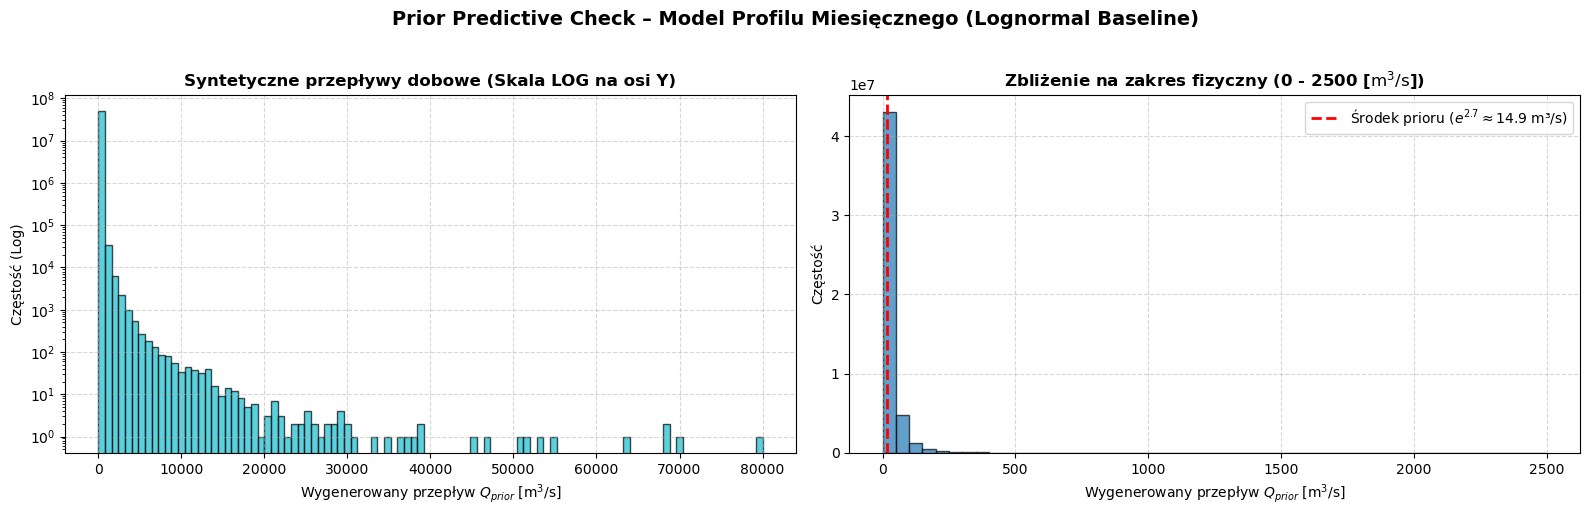


📊 OFICJALNY RAPORT PRIOR PREDICTIVE CHECK:
   • Łączna liczba wygenerowanych punktów dobowych: 50370000
   • Procent wygenerowanych ujemnych wartości:       0.00%
   • Mediana wygenerowanych przepływów:              14.95 m³/s
   • 95. percentyl przepływu w PPC:                 100.64 m³/s
   • Maksymalny wygenerowany przepływ w symulacji:   80004.88 m³/s

📊 RAPORT PRIOR PREDICTIVE CHECK:
   Liczba próbek:            50,370,000
   Mediana:                  14.95 m³/s
   75. percentyl:            32.00 m³/s
   90. percentyl:            64.94 m³/s
   95. percentyl:            100.64 m³/s
   99. percentyl:            243.39 m³/s
   99.9. percentyl:          755.22 m³/s
   % > 10,000 m³/s (Wisła): 0.001%
   % < 1 m³/s (za małe):    1.244%


In [35]:
# ====================================================================
# 1. KONFIGURACJA ŚCIEŻEK I STRUKTURY DANYCH
# ====================================================================
# Upewnij się, że SCRIPTS_DIR wskazuje na główny folder Twojego projektu
stan_file = SCRIPTS_DIR / "stan" / "river_prior_predictive.stan"

S_stations = 69
days_in_year = 365

# Tworzymy wektor miesięcy dla roku 2023 (rok nieprzestępny)
months_lengths = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
months_vector = []
for m_idx, length in enumerate(months_lengths, start=1):
    months_vector.extend([m_idx] * length)
months_vector = np.array(months_vector)

# Łączna liczba dobowych obserwacji N = 69 * 365 = 25185
N_obs = S_stations * days_in_year

# Tworzymy tablice indeksów stacji (1-69) i miesięcy (1-12) dla Stana
station_indices = np.repeat(np.arange(1, S_stations + 1), days_in_year)
month_indices = np.tile(months_vector, S_stations)

# Słownik danych wejściowych dla bloku 'data' w pliku Stan
stan_data = {
    "N": int(N_obs),
    "S": S_stations,
    "station": station_indices.tolist(),
    "month": month_indices.tolist()
}

# ====================================================================
# 2. KOMPILACJA I PRÓBKOWANIE APRIORI (MCMC)
# ====================================================================
if not stan_file.exists():
    print(f"❌ Błąd: Plik modelu Stan nie istnieje pod ścieżką: {stan_file}")
else:
    print("⏳ Kompilacja modelu Stan dla Prior Predictive Check... (to może chwilę potrwać)")
    model = CmdStanModel(stan_file=str(stan_file))
    print("✅ Model skompilowany pomyślnie!")
    
    print("\n🚀 Uruchamiam Prior Predictive Simulation (MCMC dla rozkładów a priori)...")
    # Ponieważ alpha zależy hierarchicznie od mu_alpha i sigma_alpha, używamy standardowego
    # próbkowania .sample(), aby Stan poprawnie wylosował powiązane parametry.
    prior_sample = model.sample(
        data=stan_data,
        chains=4,
        iter_sampling=500,  # 500 próbek * 4 łańcuchy = 2000 światów alternatywnych
        show_progress=True
    )
    
    # ====================================================================
    # 3. ANALIZA I WIZUALIZACJA WYNIKÓW (ArviZ)
    # ====================================================================
    # Konwertujemy wyniki do formatu InferenceData, mapując 'y_prior'
    idata = az.from_cmdstanpy(prior=prior_sample, prior_predictive=["y_prior"])
    
    # Ekstrakcja i spłaszczenie wygenerowanych syntetycznych przepływów dobowych
    y_prior_raw = idata.prior_predictive["y_prior"].values
    y_prior_flat = y_prior_raw.flatten()
    
    # Odrzucamy nieskończoności (zabezpieczenie przed skrajnymi wartościami rozkładu log-normalnego)
    y_prior_flat = y_prior_flat[np.isfinite(y_prior_flat)]
    
    # Tworzenie wykresów diagnostycznych
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=100)
    
    # Wykres 1: Pełny rozkład generowanych rzek w skali logarytmicznej na osi Y
    ax1.hist(y_prior_flat, bins=100, color='#17becf', edgecolor='black', alpha=0.7)
    ax1.set_yscale('log')
    ax1.set_title("Syntetyczne przepływy dobowe (Skala LOG na osi Y)", fontsize=12, weight='bold')
    ax1.set_xlabel("Wygenerowany przepływ $Q_{prior}$ [$\\text{m}^3/\\text{s}$]")
    ax1.set_ylabel("Częstość (Log)")
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # Wykres 2: Zoom na fizyczny zakres polskich rzek (od 0 do 2500 m3/s)
    zoom_range = y_prior_flat[(y_prior_flat >= 0) & (y_prior_flat <= 2500)]
    ax2.hist(zoom_range, bins=50, color='#1f77b4', edgecolor='black', alpha=0.7)
    ax2.set_title("Zbliżenie na zakres fizyczny (0 - 2500 [$\\text{m}^3/\\text{s}$])", fontsize=12, weight='bold')
    ax2.set_xlabel("Wygenerowany przepływ $Q_{prior}$ [$\\text{m}^3/\\text{s}$]")
    ax2.set_ylabel("Częstość")
    
    # Linia pomocnicza oznaczająca pozycję e^2.7 (Twojej wykalibrowanej mediany ~14.8 m3/s)
    ax2.axvline(np.exp(2.7), color='red', linestyle='--', linewidth=2, 
                label=f"Środek prioru ($e^{{2.7}} \\approx {np.exp(2.7):.1f}$ m³/s)")
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    fig.suptitle("Prior Predictive Check – Model Profilu Miesięcznego (Lognormal Baseline)", fontsize=14, weight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # ====================================================================
    # 4. RAPORT STATYSTYCZNY
    # ====================================================================
    print("\n" + "="*70)
    print("📊 OFICJALNY RAPORT PRIOR PREDICTIVE CHECK:")
    print(f"   • Łączna liczba wygenerowanych punktów dobowych: {len(y_prior_flat)}")
    print(f"   • Procent wygenerowanych ujemnych wartości:       {(y_prior_flat < 0).mean()*100:.2f}%")
    print(f"   • Mediana wygenerowanych przepływów:              {np.median(y_prior_flat):.2f} m³/s")
    print(f"   • 95. percentyl przepływu w PPC:                 {np.percentile(y_prior_flat, 95):.2f} m³/s")
    print(f"   • Maksymalny wygenerowany przepływ w symulacji:   {np.max(y_prior_flat):.2f} m³/s")
    print("="*70)

    print("\n" + "="*70)
    print("📊 RAPORT PRIOR PREDICTIVE CHECK:")
    print(f"   Liczba próbek:            {len(y_prior_flat):,}")
    print(f"   Mediana:                  {np.median(y_prior_flat):.2f} m³/s")
    print(f"   75. percentyl:            {np.percentile(y_prior_flat, 75):.2f} m³/s")
    print(f"   90. percentyl:            {np.percentile(y_prior_flat, 90):.2f} m³/s")
    print(f"   95. percentyl:            {np.percentile(y_prior_flat, 95):.2f} m³/s")
    print(f"   99. percentyl:            {np.percentile(y_prior_flat, 99):.2f} m³/s")
    print(f"   99.9. percentyl:          {np.percentile(y_prior_flat, 99.9):.2f} m³/s")
    print(f"   % > 10,000 m³/s (Wisła): {(y_prior_flat > 10000).mean()*100:.3f}%")
    print(f"   % < 1 m³/s (za małe):    {(y_prior_flat < 1).mean()*100:.3f}%")
    print("="*70)

Parametryzacja non-centered pomogla w rozwiazaniu problemu, niemniej trzeba zrozumiec sztuczke z transformed parameters!

# TUTAJ NA DOLE SĄ ŚMIECI!!!!

# TO JESZCZE NIE - trzeba po kolei, bez spiny

/tmp/ipykernel_13065/815859463.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(bp_data, labels=[month_names[m-1] for m in months], patch_artist=True,


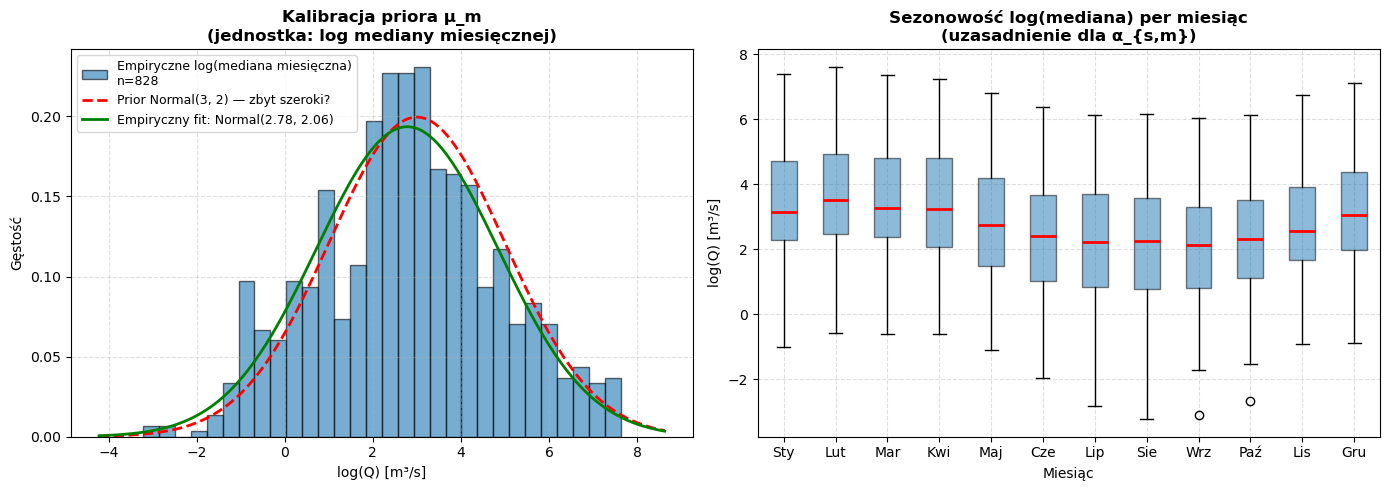


📐 Sugerowane hyperprior na podstawie danych:
   μ_m ~ Normal(2.78, 1.0)   ← lokacja
   σ_m ~ HalfNormal(2.06)  ← zmienność między stacjami


In [24]:
# Lepszy wykres 2: rozkład log(mediany miesięcznej) per stacja
monthly_log_medians = []

for file_path in sorted(csv_dir.glob("*.csv")):
    try:
        df = pd.read_csv(file_path)
        df_clean = df[df['Value'] != -999.000].copy()
        df_clean['Value'] = pd.to_numeric(df_clean['Value'], errors='coerce')
        df_clean['Date'] = pd.to_datetime(df_clean['Date'])
        df_clean['month'] = df_clean['Date'].dt.month

        for month, grp in df_clean.groupby('month'):
            med = grp['Value'].median()
            if med > 0:
                monthly_log_medians.append(np.log(med))
    except:
        pass

monthly_log_medians = np.array(monthly_log_medians)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

# --- Panel lewy: empiria vs Twój prior ---
axes[0].hist(monthly_log_medians, bins=30, density=True,
             color='#1f77b4', alpha=0.6, edgecolor='black',
             label=f'Empiryczne log(mediana miesięczna)\nn={len(monthly_log_medians)}')

emp_mu    = monthly_log_medians.mean()
emp_sigma = monthly_log_medians.std()

x = np.linspace(monthly_log_medians.min() - 1, monthly_log_medians.max() + 1, 300)

# Prior który kalibrujesz
axes[0].plot(x, stats.norm.pdf(x, 3.0, 2.0), 'r--', lw=2,
             label='Prior Normal(3, 2) — zbyt szeroki?')
# Prior dopasowany do danych
axes[0].plot(x, stats.norm.pdf(x, emp_mu, emp_sigma), 'g-', lw=2,
             label=f'Empiryczny fit: Normal({emp_mu:.2f}, {emp_sigma:.2f})')

axes[0].set_title("Kalibracja priora μ_m\n(jednostka: log mediany miesięcznej)", weight='bold')
axes[0].set_xlabel("log(Q) [m³/s]")
axes[0].set_ylabel("Gęstość")
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.4)

# --- Panel prawy: sezonowość — czy prior powinien być jeden dla wszystkich miesięcy? ---
monthly_means_by_month = {}
for file_path in sorted(csv_dir.glob("*.csv")):
    try:
        df = pd.read_csv(file_path)
        df_clean = df[df['Value'] != -999.000].copy()
        df_clean['Value'] = pd.to_numeric(df_clean['Value'], errors='coerce')
        df_clean['Date'] = pd.to_datetime(df_clean['Date'])
        df_clean['month'] = df_clean['Date'].dt.month
        for month, grp in df_clean.groupby('month'):
            med = grp['Value'].median()
            if med > 0:
                monthly_means_by_month.setdefault(month, []).append(np.log(med))
    except:
        pass

months = sorted(monthly_means_by_month.keys())
bp_data = [monthly_means_by_month[m] for m in months]
month_names = ['Sty','Lut','Mar','Kwi','Maj','Cze','Lip','Sie','Wrz','Paź','Lis','Gru']

axes[1].boxplot(bp_data, labels=[month_names[m-1] for m in months], patch_artist=True,
                boxprops=dict(facecolor='#1f77b4', alpha=0.5),
                medianprops=dict(color='red', lw=2))
axes[1].set_title("Sezonowość log(mediana) per miesiąc\n(uzasadnienie dla α_{s,m})", weight='bold')
axes[1].set_xlabel("Miesiąc")
axes[1].set_ylabel("log(Q) [m³/s]")
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"\n📐 Sugerowane hyperprior na podstawie danych:")
print(f"   μ_m ~ Normal({emp_mu:.2f}, 1.0)   ← lokacja")
print(f"   σ_m ~ HalfNormal({emp_sigma:.2f})  ← zmienność między stacjami")

Ponieważ, model opiera się na rozkładzie Log-normalnym, parametry alfa oraz ni operuja na skali logarytmicznej.

01:46:53 - cmdstanpy - INFO - compiling stan file /home/pawsooon/Documents/Vsc/DA_project/scripts/stan/river_prior_predictive.stan to exe file /home/pawsooon/Documents/Vsc/DA_project/scripts/stan/river_prior_predictive


⏳ Kompilacja modelu Stan dla Prior Predictive Check... (to może chwilę potrwać)


01:47:08 - cmdstanpy - INFO - compiled model executable: /home/pawsooon/Documents/Vsc/DA_project/scripts/stan/river_prior_predictive
01:47:08 - cmdstanpy - INFO - CmdStan start processing


✅ Model skompilowany pomyślnie!

🚀 Uruchamiam Prior Predictive Simulation dla przepływów dobowych...


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]




chain 1:  13%|█▎        | 200/1500 [00:03<00:21, 59.54it/s, (Warmup)]




chain 1:  20%|██        | 300/1500 [00:06<00:26, 45.11it/s, (Warmup)]


chain 1:  27%|██▋       | 400/1500 [00:09<00:29, 37.09it/s, (Warmup)]


chain 1:  33%|███▎      | 500/1500 [00:12<00:28, 35.61it/s, (Warmup)]


chain 1:  40%|████      | 600/1500 [00:16<00:26, 33.36it/s, (Warmup)]




chain 1:  47%|████▋     | 700/1500 [00:19<00:25, 31.98it/s, (Warmup)]



chain 1:  53%|█████▎    | 800/1500 [00:22<00:22, 31.02it/s, (Warmup)]






chain 1:  67%|██████▋   | 1000/1500 [00:29<00:16, 31.22it/s, (Sampling)]





chain 1:  73%|███████▎  | 1100/1500 [00:33<00:14, 27.57it/s, (Sampling)]


chain 1:  80%|████████  | 1200/1500 [00:38<00:11, 25.34it/s, (Sampling)]



chain 1:  87%|████████▋ | 1300/1500 [00:43<00:08, 24.07it/s, (Sampling)]

chain 2: 100%|██████████| 1500/1500 [00:52<00:00, 28.59it/s, (Sampling completed)]

chain 3: 100%|██████████| 1500/1500 


01:48:00 - cmdstanpy - INFO - CmdStan done processing.
01:48:00 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'river_prior_predictive.stan', line 24, column 6 to column 56)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'river_prior_predictive.stan', line 24, column 6 to column 56)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'river_prior_predictive.stan', line 24, column 6 to column 56)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'river_prior_predictive.stan', line 24, column 6 to column 56)
Consider re-running with show_console=True if the above output is unclear!


01:48:02 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 4 divergent transitions (0.8%)
	Chain 1 had 495 iterations at max treedepth (99.0%)
	Chain 2 had 42 divergent transitions (8.4%)
	Chain 2 had 194 iterations at max treedepth (38.8%)
	Chain 3 had 64 divergent transitions (12.8%)
	Chain 3 had 176 iterations at max treedepth (35.2%)
	Chain 4 had 45 divergent transitions (9.0%)
	Chain 4 had 403 iterations at max treedepth (80.6%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


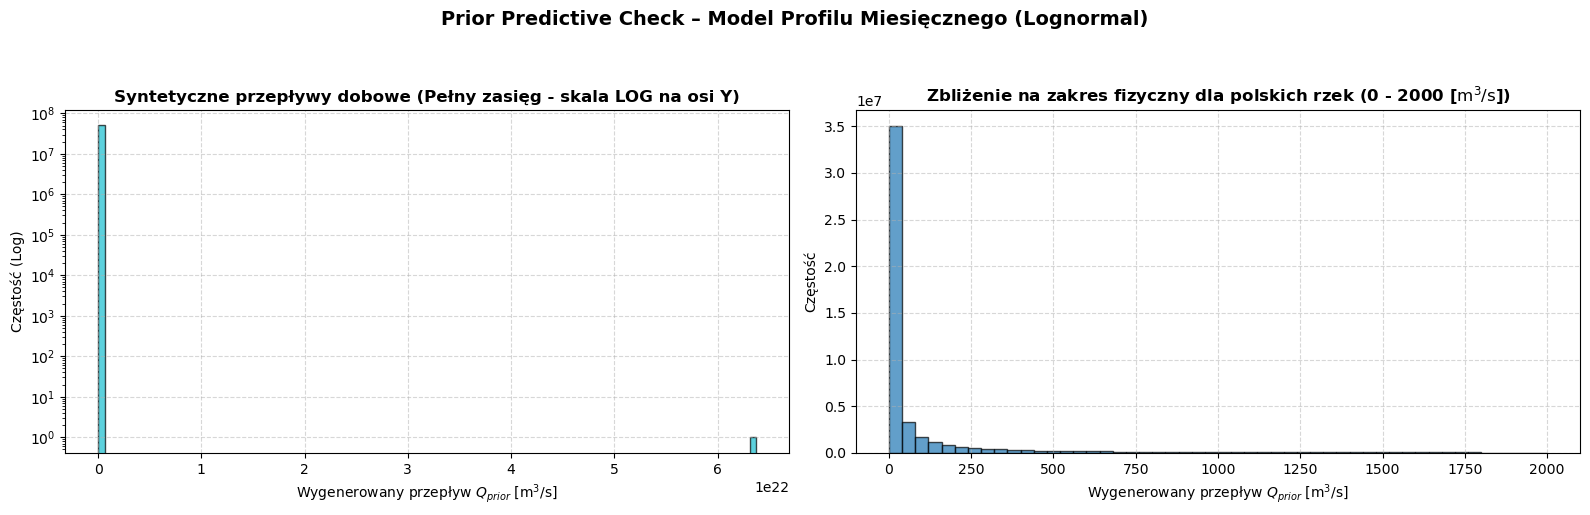


📊 RAPORT PRIOR PREDICTIVE CHECK DLA RZEK:
   • Łączna liczba wygenerowanych punktów dobowych: 50370000
   • Procent wygenerowanych ujemnych wartości:       0.00%
   • Mediana wygenerowanych przepływów:              7.12 m³/s
   • 95. percentyl przepływu w PPC:                 2271.92 m³/s
   • Maksymalny wygenerowany przepływ:               63745802000000004128768.00 m³/s


In [21]:
# 1. Definicja ścieżki do pliku Stan (dostosuj do swojej struktury)
# Zakładam, że plik nazywa się 'river_prior_predictive.stan' i zawiera kod, który stworzyliśmy krok wcześniej
stan_file =  SCRIPTS_DIR / "stan" / "river_prior_predictive.stan"

# --- PRZYGOTOWANIE STRUKTURY DANYCH DLA ROKU 2023 ---
S_stations = 69
days_in_year = 365

# Tworzymy wektor miesięcy dla jednego roku 2023 (rok nielistopadowy)
# Styczeń ma 31 dni, Luty 28, Marzec 31 itd.
months_lengths = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
months_vector = []
for m_idx, length in enumerate(months_lengths, start=1):
    months_vector.extend([m_idx] * length)
months_vector = np.array(months_vector) # Wektor 365 elementów z numerami miesięcy

# Mapujemy to na wszystkie 69 stacji
# Łączna liczba dobowych obserwacji N = 69 * 365 = 25185
N_obs = S_stations * days_in_year

# Tworzymy tablice indeksów stacji (od 1 do 69) i miesięcy (od 1 to 12) dla Stana
station_indices = np.repeat(np.arange(1, S_stations + 1), days_in_year)
month_indices = np.tile(months_vector, S_stations)

# Słownik danych, który przekazujemy do Stana (Zgodny z blokiem 'data' naszego nowego modelu)
stan_data = {
    "N": int(N_obs),
    "S": S_stations,
    "station": station_indices.tolist(),
    "month": month_indices.tolist()
}

if not stan_file.exists():
    print(f"❌ Błąd: Plik modelu Stan nie istnieje pod ścieżką: {stan_file}")
else:
    # 2. Kompilacja modelu w Stan
    print("⏳ Kompilacja modelu Stan dla Prior Predictive Check... (to może chwilę potrwać)")
    model = CmdStanModel(stan_file=str(stan_file))
    print("✅ Model skompilowany pomyślnie!")
    
    # 3. Próbkowanie wyłącznie z rozkładów a priori
    print("\n🚀 Uruchamiam Prior Predictive Simulation dla przepływów dobowych...")
    prior_sample = model.sample(
        data=stan_data,
        chains=4,
        iter_sampling=500,  # 500 próbek na 1 łańcuch = 2000 generowanych światów alternatywnych
        show_progress=True
    )
    
    # 4. Konwersja wyników do formatu ArviZ (używamy nazwy zmiennej 'y_prior' z naszego kodu Stan)
    idata = az.from_cmdstanpy(prior=prior_sample, prior_predictive=["y_prior"])
    
    # 5. Ekstrakcja wygenerowanych syntetycznych przepływów dobowych
    y_prior_raw = idata.prior_predictive["y_prior"].values
    y_prior_flat = y_prior_raw.flatten()
    
    # Odrzucamy nieskończoności, jeśli rozkład log-normalny wygenerował coś potężnego
    y_prior_flat = y_prior_flat[np.isfinite(y_prior_flat)]
    
    # 6. Wizualizacja rozkładu a priori przepływów dobowych
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=100)
    
    # Wykres 1: Pełny rozkład (skala logarytmiczna na osi Y dla lepszej widoczności ogona)
    ax1.hist(y_prior_flat, bins=100, color='#17becf', edgecolor='black', alpha=0.7)
    ax1.set_yscale('log')
    ax1.set_title("Syntetyczne przepływy dobowe (Pełny zasięg - skala LOG na osi Y)", fontsize=12, weight='bold')
    ax1.set_xlabel("Wygenerowany przepływ $Q_{prior}$ [$\\text{m}^3/\\text{s}$]")
    ax1.set_ylabel("Częstość (Log)")
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # Wykres 2: Zoom na fizycznie uzasadniony zakres polskich rzek (0 do 2000 m3/s)
    # Pozwala ocenić, czy priory dobrze lokują większość masy prawdopodobieństwa
    zoom_range = y_prior_flat[(y_prior_flat >= 0) & (y_prior_flat <= 2000)]
    ax2.hist(zoom_range, bins=50, color='#1f77b4', edgecolor='black', alpha=0.7)
    ax2.set_title("Zbliżenie na zakres fizyczny dla polskich rzek (0 - 2000 [$\\text{m}^3/\\text{s}$])", fontsize=12, weight='bold')
    ax2.set_xlabel("Wygenerowany przepływ $Q_{prior}$ [$\\text{m}^3/\\text{s}$]")
    ax2.set_ylabel("Częstość")
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    fig.suptitle("Prior Predictive Check – Model Profilu Miesięcznego (Lognormal)", fontsize=14, weight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Krótki raport statystyczny z symulacji hydrologicznej
    print("\n" + "="*50)
    print("📊 RAPORT PRIOR PREDICTIVE CHECK DLA RZEK:")
    print(f"   • Łączna liczba wygenerowanych punktów dobowych: {len(y_prior_flat)}")
    print(f"   • Procent wygenerowanych ujemnych wartości:       {(y_prior_flat < 0).mean()*100:.2f}%")
    print(f"   • Mediana wygenerowanych przepływów:              {np.median(y_prior_flat):.2f} m³/s")
    print(f"   • 95. percentyl przepływu w PPC:                 {np.percentile(y_prior_flat, 95):.2f} m³/s")
    print(f"   • Maksymalny wygenerowany przepływ:               {np.max(y_prior_flat):.2f} m³/s")
    print("="*50)